# Demo 6: Simulating Pose Segmentation Data

*Written and last updated July 19, 2025 by Sedona Ewbank, snewbank@stanford.edu*

The purpose of this demo is to demonstrate how to use the simulation functions of MARIPoSA, specifically for generating three different kinds of output data:
1. Time-series categorical pose segmentation data (generated by measuring and applying transition frequency)
2. Pose module usage data without labels
3. Pose module usage data with labels from a regression model

In [30]:
import os
import sys
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt

#This block only important for running as script
#script_dir = os.path.dirname(os.path.abspath(__file__))
mariposa_dir = "/Users/snewbank/PycharmProjects/MARIPoSA"
utils_dir = os.path.join(mariposa_dir, 'utils')
sys.path.append(utils_dir)
sys.path.append(mariposa_dir)

#import utils
from utils import metadata, analyze, plot, simulate

importlib.reload(metadata)
importlib.reload(analyze)
importlib.reload(plot)
importlib.reload(simulate)

<module 'utils.simulate' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py'>

In [31]:
demo_dir="/Users/snewbank/Behavior/MARIPoSA_demo_data/"
config=metadata.load_project(demo_dir+"250719_test/config_PS.yaml")
save=True
save_path = demo_dir+"demo_figures/"
if not os.path.exists(save_path):
    os.makedirs(save_path)

## 6.1: Simulating time-series categorical pose segmentation data

The most granular form of simulation in MARIPoSA is to simulate time-series categorical pose segmentation data to generate new data emulating existing data. This is acheived in simulate.generate_sequence(), which outputs a pose module labels dataframe in the same format as analyze.get_module_labels (with pose module usage and transition probabilities based on the input labels_df). The simulated labels dataframe output will have the same group structure as the input data (if there are subgroups, it will have subgroups).

In [32]:
labels_df = analyze.get_module_labels(config,0,1200,subgroups=["sal"])
sim_labels_df = simulate.generate_sequence(config,labels_df,1200*int(config["fps"]),n_subjs=20,verbose=True)

Analyzing input labels dataframe


/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py:218: RuntimeWarning: invalid value encountered in divide
  transition_mat = transition_mat / row_sums[:, np.newaxis]


Generating data for subject 1 of 20
Generating data for subject 2 of 20
Generating data for subject 3 of 20
Generating data for subject 4 of 20
Generating data for subject 5 of 20
Generating data for subject 6 of 20
Generating data for subject 7 of 20
Generating data for subject 8 of 20
Generating data for subject 9 of 20
Generating data for subject 10 of 20
Generating data for subject 11 of 20
Generating data for subject 12 of 20
Generating data for subject 13 of 20
Generating data for subject 14 of 20
Generating data for subject 15 of 20
Generating data for subject 16 of 20
Generating data for subject 17 of 20
Generating data for subject 18 of 20
Generating data for subject 19 of 20
Generating data for subject 20 of 20


Text(0.5, 1.0, 'Simulated data')

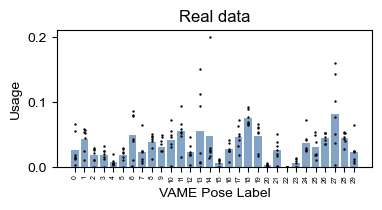

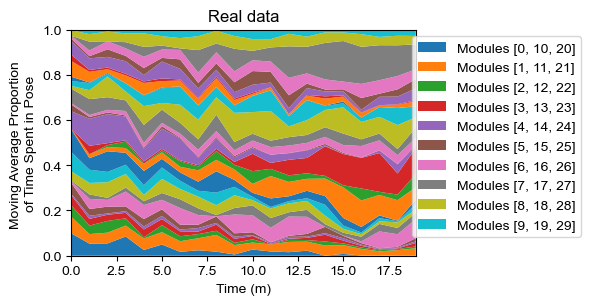

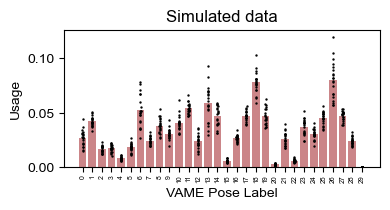

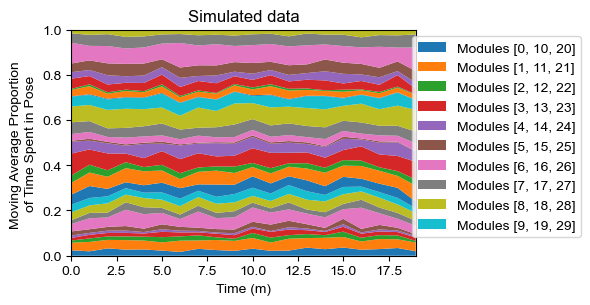

In [33]:
real_usage = analyze.get_module_usage(config,labels_df)
plot.plot_module_usage(config,real_usage,cmap="Blues_r")
plt.title("Real data")
real_usage = analyze.get_module_usage(config,labels_df,binsize=60)
plot.module_usage_sandplot(config,real_usage)
plt.title("Real data")

sim_usage = analyze.get_module_usage(config,sim_labels_df)
plot.plot_module_usage(config,sim_usage,cmap="Reds_r")
plt.title("Simulated data")
sim_usage = analyze.get_module_usage(config,sim_labels_df,binsize=60)
plot.module_usage_sandplot(config,sim_usage)
plt.title("Simulated data")

In [34]:
labels_df = analyze.get_module_labels(config,0,1200,subgroups=["sal","k1","k5","k10"])
sim_labels_df = simulate.generate_sequence(config,labels_df,1200*int(config["fps"]),n_subjs=5)

/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py:253: RuntimeWarning: invalid value encountered in divide
  header = subj_i
/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py:253: RuntimeWarning: invalid value encountered in divide
  header = subj_i
/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py:253: RuntimeWarning: invalid value encountered in divide
  header = subj_i
/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py:253: RuntimeWarning: invalid value encountered in divide
  header = subj_i


Text(0.5, 1.0, 'Simulated data')

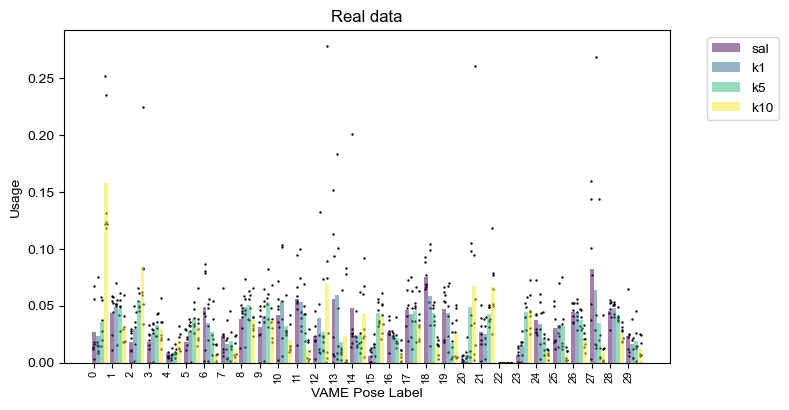

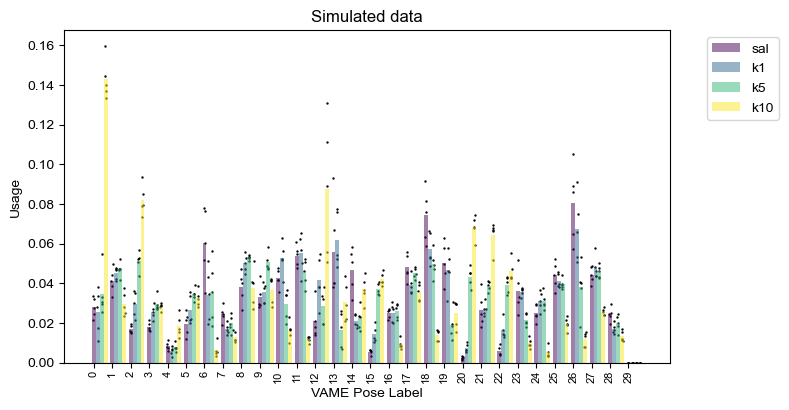

In [35]:
real_usage = analyze.get_module_usage(config,labels_df)
plot.plot_module_usage(config,real_usage,cmap="viridis",figH=4,figW=8)
plt.title("Real data")


sim_usage = analyze.get_module_usage(config,sim_labels_df)
plot.plot_module_usage(config,sim_usage,cmap="viridis",figH=4,figW=8)
plt.title("Simulated data")


## 6.2: Simulating module usage

Since many analyses can be performed on pose module usage summary data without the full time-series categorical sequence of pose modules, it is also possible to just simulate pose module usage based on input data, as shown below, using simulate.generate_usage (to generate module usage with no group labels) or simulate.generate_usage_labeled (to generate module usage with continuous labels based on a regression model).

Iter 500: 69.3% samples generated (18 of 20 bins not filled)
Iter 1000: 95.3% samples generated (4 of 20 bins not filled)
Iter 1500: 99.8% samples generated (1 of 20 bins not filled)


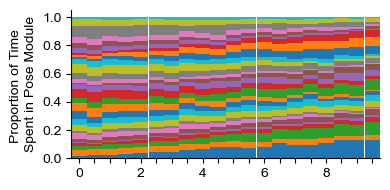

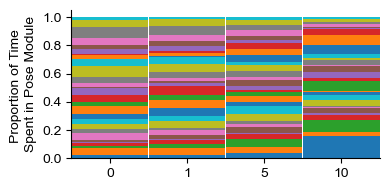

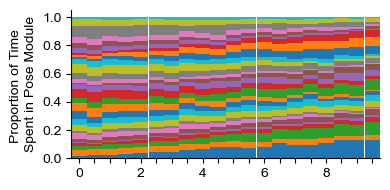

In [36]:
labels_df = analyze.get_module_labels(config, 0, 1200, subgroups=["sal","k1","k5","k10"])
module_usage = analyze.get_module_usage(config, labels_df)
plot.plot_module_usage(config,module_usage,style="stacked",legend=False,alt_xticks=[0,1,5,10])

dose_dict={'sal': 0, 'k1': 1, 'k5': 5, 'k10': 10}
reg, dose_labels = analyze.regress(module_usage, dose_dict)

bin_low = np.arange(0,10,0.5)
bin_high = np.arange(0,10,0.5)+0.5
bins = np.array([bin_low,bin_high]).T

#sim_module_usage_sal = simulate.generate_usage(sal_module_usage, 1000, random_state=rs, mode="multivariate_gaussian")
sim_module_usage = simulate.generate_usage_labeled(module_usage, 30, bins, reg, max_iters = 1e100, mode="multivariate_gaussian",verbosity="medium")

ticks=[]
for i in list(sim_module_usage.group_dict.keys()): 
    if i%2==0:
        ticks.append(str(int(i)))
    else:
        ticks.append("")

plot.plot_module_usage(config,sim_module_usage,style="stacked",legend=False,alt_xticks=ticks)